# Quantum Segment-Level Analysis — store-backed (statevector)

Reads the decoupled **`qtrk_store`** via `qtrk_view` (metrics recomputed as a VIEW — never the old relative tau*max, never the baked pkl metrics).

**Headline operating point = wp99 (high-efficiency working point).** Per solver, per config, the activation threshold tau is placed just below the (1 − 0.99) quantile of the *true* segment amplitudes, so ~99 % of the true segments stay active and we quote the false rate paid. This is the LHCb-style picture: **recover all the true segments, kill the false ones.** The fixed gamma-aware absolute cut (tau = delta/(delta+gamma)+0.10 = 0.35 at gamma=3) is the *low-false-rate* choice; for the 1BQF it chops the reshaped outer true band and pins efficiency at the artificial ~75 % plateau ("the cut, not lost physics"). It is kept in the figures below only as a **faded diagnostic** so the contrast that motivated the 1BQF stays visible. See `WP99_REFRESH_LOG.md`.

**Scope:** statevector-only campaign. The old notebook's downstream-tracking figure and its statevector-vs-sampling/hires comparison suite (Sec 7e-7q) are intentionally omitted — the store has no `get_tracks` and no sampling readout. Figures fill in as the Condor quantum jobs drain.

In [1]:
# Setup
import sys, pathlib
sys.path.insert(0, '/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/_shared')
sys.path.insert(0, '/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Verify_new_results')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import qtrk_view as V

STUDY = 'Verify_new_results'
OUT = pathlib.Path('outputs/quantum_segment_analysis/store_backed'); OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'font.size':12,'axes.grid':True,'grid.alpha':0.3,'lines.markersize':7,'lines.linewidth':2})
cC, cQ, cT, cF = '#444444', '#2166ac', '#1b7837', '#c51b7d'

def _err(ax, a, col, fmt='o-', color=None, label=None, mfc=None):
    if a is None or len(a)==0 or f'{col}_mean' not in a.columns: return
    ax.errorbar(a['n_trk'], a[f'{col}_mean'], yerr=a[f'{col}_sem'], fmt=fmt, color=color,
                capsize=4, mfc=mfc, markeredgecolor='black', markeredgewidth=0.7, label=label, zorder=3)
def _save(fig, stem):
    fig.savefig(OUT/f'{stem}.pdf', bbox_inches='tight')
    fig.savefig(OUT/f'{stem}.png', dpi=150, bbox_inches='tight'); print('saved', stem)
def _aggcols(df, cols):
    g=df.groupby('n_trk'); out=pd.DataFrame({'n_trk':sorted(df.n_trk.unique())}).set_index('n_trk')
    for c in cols:
        out[f'{c}_mean']=g[c].mean(); out[f'{c}_sem']=g[c].apply(lambda x: x.std(ddof=1)/np.sqrt(len(x)) if len(x)>1 else 0.0)
    return out.reset_index()
print('tau =', V.threshold())

tau = 0.35


In [2]:
# Load the store view (statevector); pair classical+quantum; raw vectors for diagnostics
view = V.load_view(study=STUDY)              # tidy metric view (fixed-tau + wp99 columns)
m    = V.paired(view)                          # one row per (event,ham): classical + quantum
agg  = V.aggregate(m)                          # per-T mean/sem (fixed-tau AND wp99 eff/pur/far/cos)
recs = V.vector_records(view)                  # raw sol_C/sol_Q_scaled/truth per event
print(f'paired quantum points: {len(m)}  | T = {sorted(m.n_trk.unique()) if len(m) else []}  | reps total = {len(recs)}')
if len(agg):
    have_wp = 'eff_Q_wp_mean' in agg.columns
    cols = ['n_trk','n_reps','eff_C_mean','eff_Q_mean','far_Q_mean','cos_mean']
    if have_wp:
        cols = ['n_trk','n_reps','eff_Q_mean','far_Q_mean','eff_Q_wp_mean','far_Q_wp_mean','tau_wp_Q_mean','cos_mean']
        print('HEADLINE = wp99 (eff>=99%); *_Q_mean columns are the faded fixed-tau=0.35 diagnostic\n')
    else:
        print('NOTE: wp99 columns absent — re-run build_metrics.py to add segment_*_wp\n')
    print(agg[cols].round(4).to_string(index=False))
else:
    print('(no quantum solves in the store for this study yet — figures will be empty until Condor drains)')

paired quantum points: 428  | T = [np.int64(10), np.int64(20), np.int64(30), np.int64(50), np.int64(75), np.int64(100), np.int64(150), np.int64(200), np.int64(300), np.int64(400), np.int64(550), np.int64(700), np.int64(1000)]  | reps total = 432
HEADLINE = wp99 (eff>=99%); *_Q_mean columns are the faded fixed-tau=0.35 diagnostic

 n_trk  n_reps  eff_Q_mean  far_Q_mean  eff_Q_wp_mean  far_Q_wp_mean  tau_wp_Q_mean  cos_mean
    10      26      0.7404      0.0000         1.0000         0.0000         0.1801    0.9668
    20      26      0.7452      0.0000         0.9970         0.0009         0.1594    0.9667
    30      20      0.7422      0.0000         0.9952         0.0017         0.1441    0.9667
    50      26      0.7432      0.0005         0.9968         0.0076         0.1451    0.9668
    75      20      0.7437      0.0002         0.9971         0.0252         0.1621    0.9667
   100      16      0.7428      0.0004         0.9973         0.0320         0.1576    0.9667
   150    

saved fig1_segment_metrics


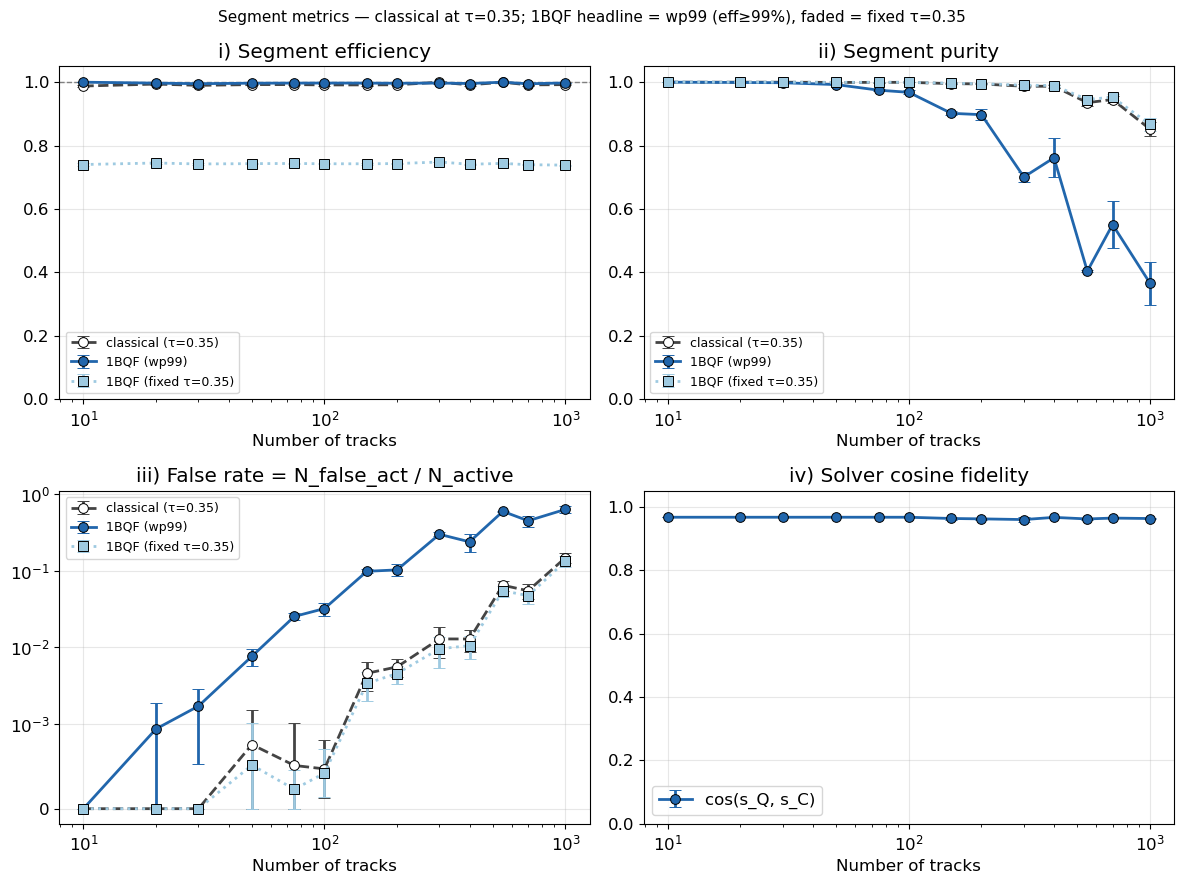

In [3]:
# Fig 1 — segment metrics vs T. CLASSICAL at its fixed τ=0.35 operating point;
# 1BQF HEADLINE = wp99 high-efficiency working point (τ holds ~99% of true
# segments) + a FADED fixed-τ=0.35 1BQF curve (the ~75% plateau — the cut, not
# lost physics). The wp99 1BQF recovers all true segments; the cost is far (iii).
cQ_fix = '#9ecae1'   # faded blue = fixed τ=0.35 1BQF diagnostic
hwp = 'eff_Q_wp_mean' in agg.columns
fig, ax = plt.subplots(2,2, figsize=(12,9))
# i) efficiency
_err(ax[0,0],agg,'eff_C','o--',cC,'classical (τ=0.35)',mfc='white')
if hwp:
    _err(ax[0,0],agg,'eff_Q_wp','o-',cQ,'1BQF (wp99)')
    _err(ax[0,0],agg,'eff_Q','s:',cQ_fix,'1BQF (fixed τ=0.35)')
else:
    _err(ax[0,0],agg,'eff_Q','o-',cQ,'1BQF')
ax[0,0].axhline(1,color='gray',ls='--',lw=1); ax[0,0].set_ylim(0,1.05); ax[0,0].set_title('i) Segment efficiency'); ax[0,0].legend(loc='lower left', fontsize=9)
# ii) purity
_err(ax[0,1],agg,'pur_C','o--',cC,'classical (τ=0.35)',mfc='white')
if hwp:
    _err(ax[0,1],agg,'pur_Q_wp','o-',cQ,'1BQF (wp99)')
    _err(ax[0,1],agg,'pur_Q','s:',cQ_fix,'1BQF (fixed τ=0.35)')
else:
    _err(ax[0,1],agg,'pur_Q','o-',cQ,'1BQF')
ax[0,1].set_ylim(0,1.05); ax[0,1].set_title('ii) Segment purity'); ax[0,1].legend(loc='lower left', fontsize=9)
# iii) false rate
_err(ax[1,0],agg,'far_C','o--',cC,'classical (τ=0.35)',mfc='white')
if hwp:
    _err(ax[1,0],agg,'far_Q_wp','o-',cQ,'1BQF (wp99)')
    _err(ax[1,0],agg,'far_Q','s:',cQ_fix,'1BQF (fixed τ=0.35)')
else:
    _err(ax[1,0],agg,'far_Q','o-',cQ,'1BQF')
ax[1,0].set_yscale('symlog',linthresh=1e-3); ax[1,0].set_title('iii) False rate = N_false_act / N_active'); ax[1,0].legend(loc='upper left', fontsize=9)
# iv) cosine fidelity (threshold-free)
_err(ax[1,1],agg,'cos','o-',cQ,'cos(s_Q, s_C)')
ax[1,1].set_ylim(0,1.05); ax[1,1].set_title('iv) Solver cosine fidelity'); ax[1,1].legend(loc='lower left')
for a in ax.flat: a.set_xlabel('Number of tracks'); a.set_xscale('log')
fig.suptitle('Segment metrics — classical at τ=0.35; 1BQF headline = wp99 (eff≥99%), faded = fixed τ=0.35', fontsize=11)
fig.tight_layout(); _save(fig,'fig1_segment_metrics'); plt.show()

saved fig2_fidelity


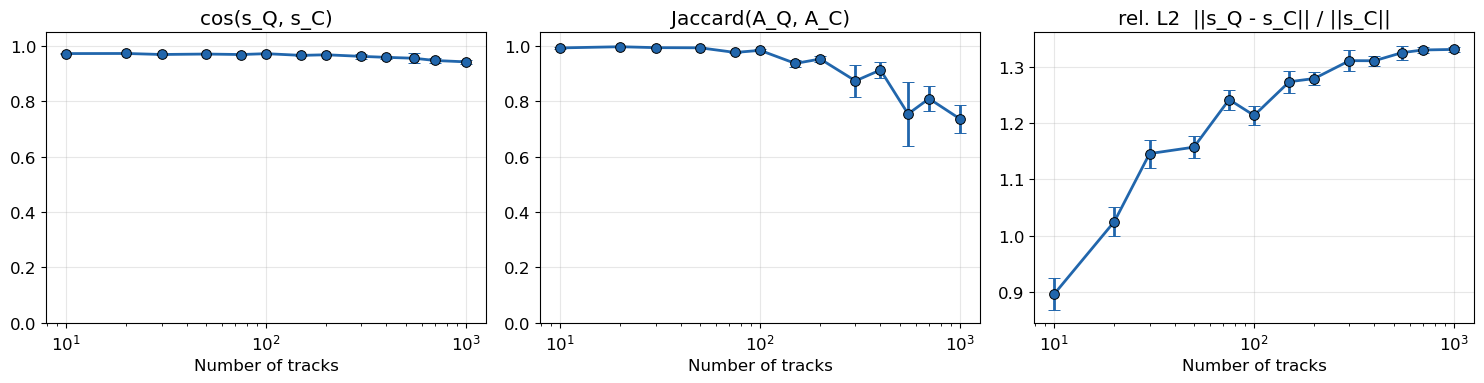

In [4]:
# Fig 2 — solution-vector fidelity (cosine, Jaccard of active sets, relative L2) vs T
df = V.records_df(view)
fig, ax = plt.subplots(1,3, figsize=(15,4))
if len(df):
    fid = _aggcols(df, ['cosine','jaccard','rel_l2'])
    for j,(c,t) in enumerate([('cosine','cos(s_Q, s_C)'),('jaccard','Jaccard(A_Q, A_C)'),('rel_l2','rel. L2  ||s_Q - s_C|| / ||s_C||')]):
        _err(ax[j],fid,c,'o-',cQ); ax[j].set_title(t); ax[j].set_xlabel('Number of tracks'); ax[j].set_xscale('log')
    ax[0].set_ylim(0,1.05); ax[1].set_ylim(0,1.05)
fig.tight_layout(); _save(fig,'fig2_fidelity'); plt.show()

saved fig3_timing


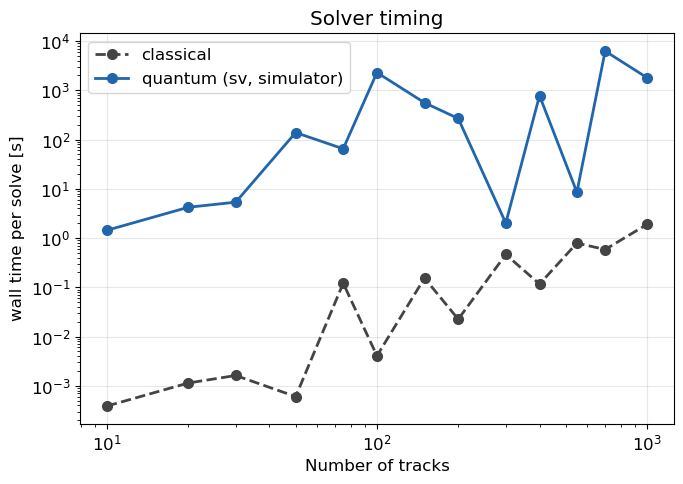

In [5]:
# Fig 3 — solver timing vs T (recorded t_solve from the store)
fig, axx = plt.subplots(figsize=(7,5))
if len(m):
    g=m.groupby('n_trk'); tim=pd.DataFrame({'n_trk':sorted(m.n_trk.unique())})
    tim['tC']=g['t_solve_C'].mean().values; tim['tQ']=g['t_solve_Q'].mean().values
    axx.plot(tim.n_trk,tim.tC,'o--',color=cC,label='classical'); axx.plot(tim.n_trk,tim.tQ,'o-',color=cQ,label='quantum (sv, simulator)')
    axx.set_xscale('log'); axx.set_yscale('log')
axx.set_xlabel('Number of tracks'); axx.set_ylabel('wall time per solve [s]'); axx.set_title('Solver timing'); axx.legend()
fig.tight_layout(); _save(fig,'fig3_timing'); plt.show()

saved fig4_seg14e_mirror


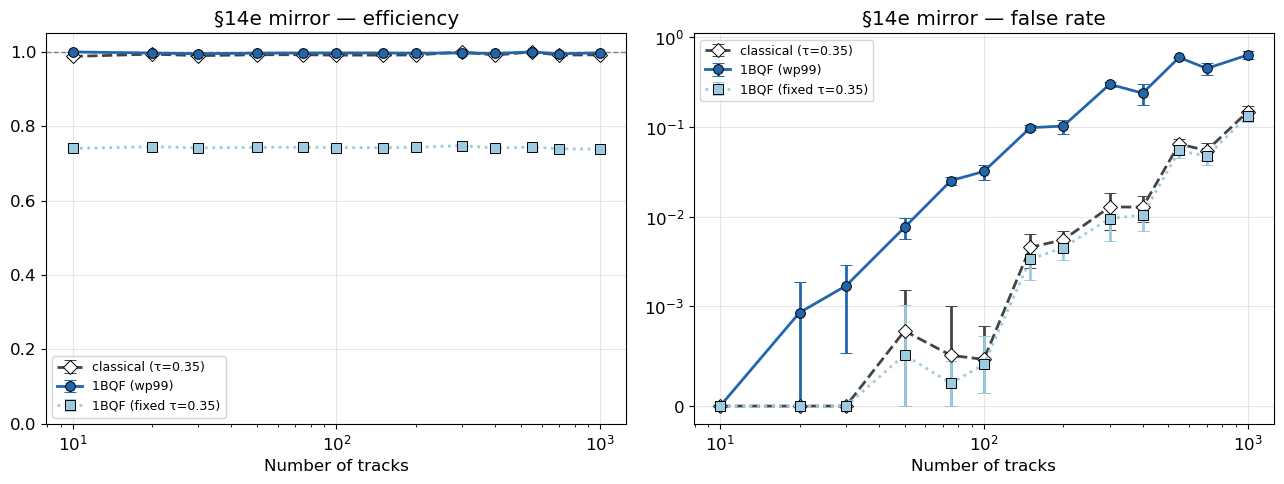

In [6]:
# Fig 4 — §14e mirror: efficiency & false rate. CLASSICAL at fixed τ=0.35;
# 1BQF headline = wp99 + faded fixed-τ diagnostic.
hwp = 'eff_Q_wp_mean' in agg.columns
fig, ax = plt.subplots(1,2, figsize=(13,5))
_err(ax[0],agg,'eff_C','D--',cC,'classical (τ=0.35)',mfc='white')
_err(ax[1],agg,'far_C','D--',cC,'classical (τ=0.35)',mfc='white')
if hwp:
    _err(ax[0],agg,'eff_Q_wp','o-',cQ,'1BQF (wp99)')
    _err(ax[0],agg,'eff_Q','s:',cQ_fix,'1BQF (fixed τ=0.35)')
    _err(ax[1],agg,'far_Q_wp','o-',cQ,'1BQF (wp99)')
    _err(ax[1],agg,'far_Q','s:',cQ_fix,'1BQF (fixed τ=0.35)')
else:
    _err(ax[0],agg,'eff_Q','o-',cQ,'1BQF')
    _err(ax[1],agg,'far_Q','o-',cQ,'1BQF')
ax[0].axhline(1,color='gray',ls='--',lw=1); ax[0].set_ylim(0,1.05); ax[0].set_title('§14e mirror — efficiency'); ax[0].legend(loc='lower left', fontsize=9)
ax[1].set_yscale('symlog',linthresh=1e-3); ax[1].set_title('§14e mirror — false rate'); ax[1].legend(loc='upper left', fontsize=9)
for a in ax: a.set_xlabel('Number of tracks'); a.set_xscale('log')
fig.tight_layout(); _save(fig,'fig4_seg14e_mirror'); plt.show()

saved fig5_threshold_abs_vs_rel


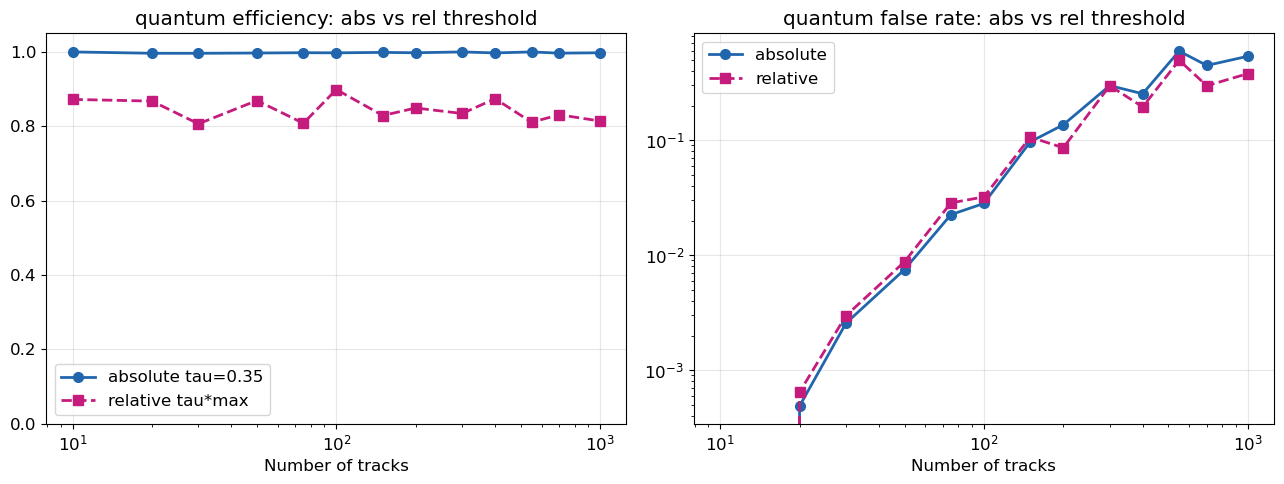

In [7]:
# Fig 5 — threshold fix: quantum absolute tau=0.35 vs relative tau*max (from raw vectors)
tau=V.threshold(); rows=[]
for r in recs:
    sQ=r.get('sol_Q_scaled')
    if sQ is None: continue
    tr=r['truth']; ntc=max(int(tr.sum()),1)
    aA=sQ>tau; qm=float(sQ.max()); aR=(sQ>tau*qm) if qm>0 else np.zeros_like(sQ,bool)
    rows.append(dict(n_trk=r['n_trk'],
        eff_abs=(aA&tr).sum()/ntc, far_abs=(aA&~tr).sum()/max(int(aA.sum()),1),
        eff_rel=(aR&tr).sum()/ntc, far_rel=(aR&~tr).sum()/max(int(aR.sum()),1)))
fig, ax = plt.subplots(1,2, figsize=(13,5))
if rows:
    g=pd.DataFrame(rows).groupby('n_trk').mean().reset_index()
    ax[0].plot(g.n_trk,g.eff_abs,'o-',color=cQ,label='absolute tau=0.35'); ax[0].plot(g.n_trk,g.eff_rel,'s--',color=cF,label='relative tau*max')
    ax[0].set_ylim(0,1.05); ax[0].set_title('quantum efficiency: abs vs rel threshold'); ax[0].legend()
    ax[1].plot(g.n_trk,g.far_abs,'o-',color=cQ,label='absolute'); ax[1].plot(g.n_trk,g.far_rel,'s--',color=cF,label='relative')
    ax[1].set_yscale('log'); ax[1].set_title('quantum false rate: abs vs rel threshold'); ax[1].legend()
    for a in ax: a.set_xlabel('Number of tracks'); a.set_xscale('log')
else: print('no quantum vectors yet')
fig.tight_layout(); _save(fig,'fig5_threshold_abs_vs_rel'); plt.show()

saved fig6_leakage_auc


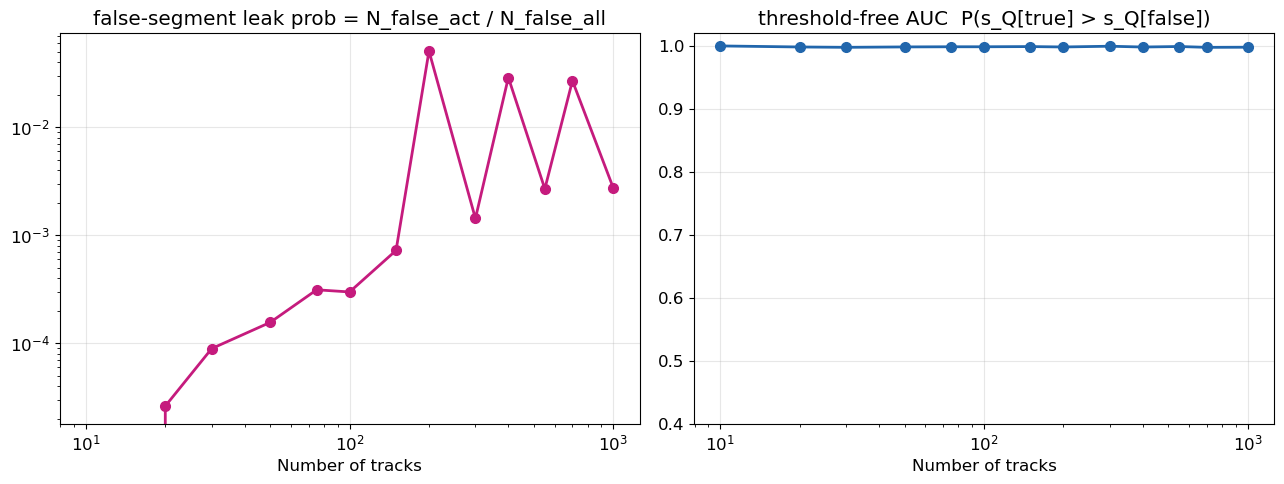

In [8]:
# Fig 6 — false-segment leakage probability and threshold-free AUC (from raw vectors)
def _auc(s,tr):
    s=np.asarray(s,float); tr=np.asarray(tr,bool); n1=int(tr.sum()); n0=int((~tr).sum())
    if not n1 or not n0: return np.nan
    rank=np.argsort(np.argsort(s))+1
    return (rank[tr].sum()-n1*(n1+1)/2)/(n1*n0)
tau=V.threshold(); rows=[]
for r in recs:
    sQ=r.get('sol_Q_scaled')
    if sQ is None: continue
    tr=r['truth']; nf=max(int((~tr).sum()),1)
    rows.append(dict(n_trk=r['n_trk'], p_leak=(sQ[~tr]>tau).sum()/nf, auc=_auc(sQ,tr)))
fig, ax = plt.subplots(1,2, figsize=(13,5))
if rows:
    g=pd.DataFrame(rows).groupby('n_trk').mean().reset_index()
    ax[0].plot(g.n_trk,g.p_leak,'o-',color=cF); ax[0].set_yscale('log')
    ax[0].set_title('false-segment leak prob = N_false_act / N_false_all'); ax[0].set_xlabel('Number of tracks'); ax[0].set_xscale('log')
    ax[1].plot(g.n_trk,g.auc,'o-',color=cQ); ax[1].set_ylim(0.4,1.02)
    ax[1].set_title('threshold-free AUC  P(s_Q[true] > s_Q[false])'); ax[1].set_xlabel('Number of tracks'); ax[1].set_xscale('log')
else: print('no quantum vectors yet')
fig.tight_layout(); _save(fig,'fig6_leakage_auc'); plt.show()

## Notes / provenance

- Source of truth: `/data/bfys/gscriven/qtrk_store` (events regenerated on demand; solutions content-addressed; metrics recomputed via `qtrk_view`/`qtrk_pipeline.load_metrics`).
- **Headline threshold = wp99 high-efficiency working point** (per-solve tau just below the 1 % quantile of the true-segment amplitudes → eff ≥ 99 %; `segment_*_wp` columns in `metrics.csv`). The fixed gamma-aware absolute cut (0.35 at gamma=3) is kept only as the faded diagnostic in Figs 1 & 4. False rate = `N_false_active / N_active`.
- **The wp99 story:** at the working point the 1BQF recovers ~100 % segment efficiency at every T (vs the ~75 % plateau the fixed cut produced); the genuine cost is the false rate, which climbs with multiplicity as the 1BQF's outer true band overlaps the coupled-false segments. Classical pays a much smaller false rate for the same efficiency.
- **Omitted vs the old notebook (statevector-only store):** downstream tracking (Fig 3 old), and the statevector-vs-sampling / hires-sampling comparison suite (Sec 7e-7q). Re-enable sampling in the Condor campaign to restore those.
- Figs 5 & 6 are threshold-diagnostic (absolute-vs-relative convention; leakage + threshold-free AUC) and are deliberately left as-is.